In [1]:
import sys
from pathlib import Path
import h5py
import numpy as np
import polars as pl
import re
import lightgbm as lgb
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(font_scale=1.5, palette='Set2')
sns.set_style('whitegrid')

DATA_DIR = Path("../data")
STRAINS_RETRO = [
    'HIV-1:CH058', 'HIV-2:GH-1', 'HIV-2:ROD', 'HIV-1:REJO',
    'Human_T-Lymphoma_Virus:Type_3', 'Human_T-Lymphoma_Virus:Type_2',
    'Human_T-Lymphoma_Virus:Type_1',
]


### Data

**NOTE**: We use Sei track predictions for transcription factors expected to primarily regulate the HIV-1 LTR core promoter: ATF, SP, RELA (NF-κB), ETS, and USF.

In [2]:
dataset = (
    pl.read_csv(DATA_DIR / "OL53.csv")
    .filter(~pl.col("sequence").is_null())
    .unique(subset=["sequence"], keep="first")
    .sort("ID", "sequence")
)

dataset = dataset.with_columns(pl.arange(dataset.height).alias("index"))

rows = []
with open(DATA_DIR / 'sei_model/target.names', 'r') as f:
    for line in f:
        parts = [p.strip() for p in line.strip().split('|')]
        if len(parts) == 3:
            cell_type, target, id_field = parts
        elif len(parts) == 4:  # e.g., line 19920 is "A549 | CTCF | ENCODE | 1"
            cell_type = parts[0]
            target = parts[1]
            id_field = 'ENCODE_' + parts[3]
        else:
            print(f"Skipping malformed line: {line}")
            continue
        rows.append([cell_type, target, id_field, line.strip()])
sei_tracks = pl.DataFrame(rows, schema=['cell_type', 'target', 'source', 'ID'], orient="row")

TFs = ['ATF', 'SP', 'RELA', 'ETS', 'USF']
pattern = r'^(?:' + '|'.join(re.escape(tf) for tf in TFs) + r')\d{0,2}$'
tf_tracks = sei_tracks.filter(pl.col("target").str.contains(pattern))
print(f"Sei tracks: {', '.join(tf_tracks["target"].unique())}")

tf_tracks.write_csv(DATA_DIR / "bst_model_tf_tracks.csv")


Sei tracks: ATF1, ETS2, SP7, SP4, ETS1, ATF4, SP3, SP1, ATF5, SP2, USF2, ATF2, ATF3, USF1, RELA


**Sei Predictions**

Predictions are obtained in [`04_obtain_sei_predictions.py`](../scripts/04_obtain_sei_predictions.py) script.

In [3]:
with h5py.File(DATA_DIR / 'OL53_sei_predictions.h5', 'r') as h5f:
    tile_ids = h5f['ID'].asstr()[:]
    all_cols = h5f['track_names'].asstr()[:]
    target_cols = tf_tracks["ID"].to_list()
    col_map = {name: i for i, name in enumerate(all_cols)}
    indices = [col_map[name] for name in target_cols]
    track_predictions = pl.from_numpy(
        h5f['track_predictions'][:][:, indices], 
        schema=target_cols
    ).with_columns(ID=tile_ids).select("ID", pl.exclude("ID"))

assert all(dataset["ID"].to_numpy() == tile_ids)


### GBDT on selected Sei outputs

Define the target experiment (Jurkat + TNF or Jurkat + CD3+PMA).

**NOTE**: We only select tiles for which the variance between replicates is small enough.

In [4]:
# # Jurkat + TNF (log2 ratio TNF / control)
target_column = 'lfc_mean_TNFEffect'
target_column_var = 'lfc_mean_variance_Berkay_Jurkat_TNF'
dataset = dataset.with_columns((pl.col("lfc_mean_Berkay_Jurkat_TNF") - pl.col("lfc_mean_Berkay_Jurkat_Ctrl")).alias(target_column))

# # Jurkat + CD3+PMA
# target_column = 'lfc_mean_StimEffect'
# target_column_var = 'lfc_mean_variance_StimEffect'

target_df = dataset.filter(
    (~pl.col(target_column).is_null()) &
    (pl.col(target_column).abs() >= 10 * pl.col(target_column_var)) &  # NOTE: filter out tiles with large variance across replicates
    (pl.col("strain").is_in(STRAINS_RETRO))
)

print(f"Final dataset: {target_df.height} tiles.")


Final dataset: 11088 tiles.


Train / validation / test split per tile id (ID_OL49)

In [ ]:
def add_stratified_split(
    df: pl.DataFrame,
    group_col: str,
    train_fraction: float, 
    valid_fraction: float, 
    random_seed: int = 42
) -> pl.DataFrame:
    assert train_fraction + valid_fraction <= 1

    return df.with_columns(
        pl.len().over(group_col).alias("_n_group"),
        pl.col(group_col).rank(method="random", seed=random_seed).over(group_col).alias("_rank")
    ).with_columns(
        pl.when(pl.col("_rank") <= (pl.col("_n_group") * train_fraction).cast(pl.Int64))
        .then(pl.lit("train"))
        .when(pl.col("_rank") <= (pl.col("_n_group") * (train_fraction + valid_fraction)).cast(pl.Int64))
        .then(pl.lit("val"))
        .otherwise(pl.lit("test"))
        .alias("split_gbdt")
    ).drop("_n_group", "_rank")


target_df = add_stratified_split(
    target_df, 
    group_col="ID_OL49", 
    train_fraction=0.7, 
    valid_fraction=0.15,
    random_seed=42
)


Model train and prediction.

In [6]:
param = {
    'num_leaves': 100,
    'deterministic': True,
    'max_depth': 15,
    'min_data_in_leaf': 5,
    # 'min_gain_to_split': 1e-3,  # regularization
    # 'min_child_weight': 1,  # regularization
    'learning_rate': 0.04,
    'boosting': 'gbdt',
    'objective': 'rmse',
    'num_iterations': 3000,  # alias for 'n_estimators'
    'feature_fraction': .25,
}

tile = 'HIV-1:REJO:6'
tile_df = target_df.filter(pl.col("ID_OL49").str.starts_with(tile))

# # Jurkat + TNF (log2 ratio TNF / control)
model_path = DATA_DIR / f"{tile.replace(':', '_')}_Jurkat_TNF_model.txt"

# # Jurkat + CD3+PMA
# model_path = DATA_DIR / f"{tile.replace(':', '_')}_Jurkat_CD3-PMA_model.txt"

train_df = tile_df.filter(pl.col("split_gbdt") == "train")
valid_df = tile_df.filter(pl.col("split_gbdt") == "val")
test_df = tile_df.filter(pl.col("split_gbdt") == "test")

X_tr = track_predictions[train_df["index"]].drop("ID").to_numpy()
y_tr = train_df[target_column].to_numpy()

X_val = track_predictions[valid_df["index"]].drop("ID").to_numpy()
y_val = valid_df[target_column].to_numpy()

X_test = track_predictions[test_df["index"]].drop("ID").to_numpy()
y_test = test_df[target_column].to_numpy()

print(f"{y_tr.shape[0]} train, {y_val.shape[0]} validation, {y_test.shape[0]} test tiles")

# # TRAINING
# feature_name = tf_tracks["ID"].str.replace(' | ', '-').str.replace(':', '.')
# train_data = lgb.Dataset(X_tr, label=y_tr, feature_name=feature_name.to_list())
# val_data = lgb.Dataset(X_val, label=y_val, feature_name=feature_name.to_list())
# bst = lgb.train(param, train_data, valid_sets=[val_data], callbacks=[lgb.early_stopping(stopping_rounds=50)])
# bst.save_model(model_path)


1254 train, 269 validation, 269 test tiles


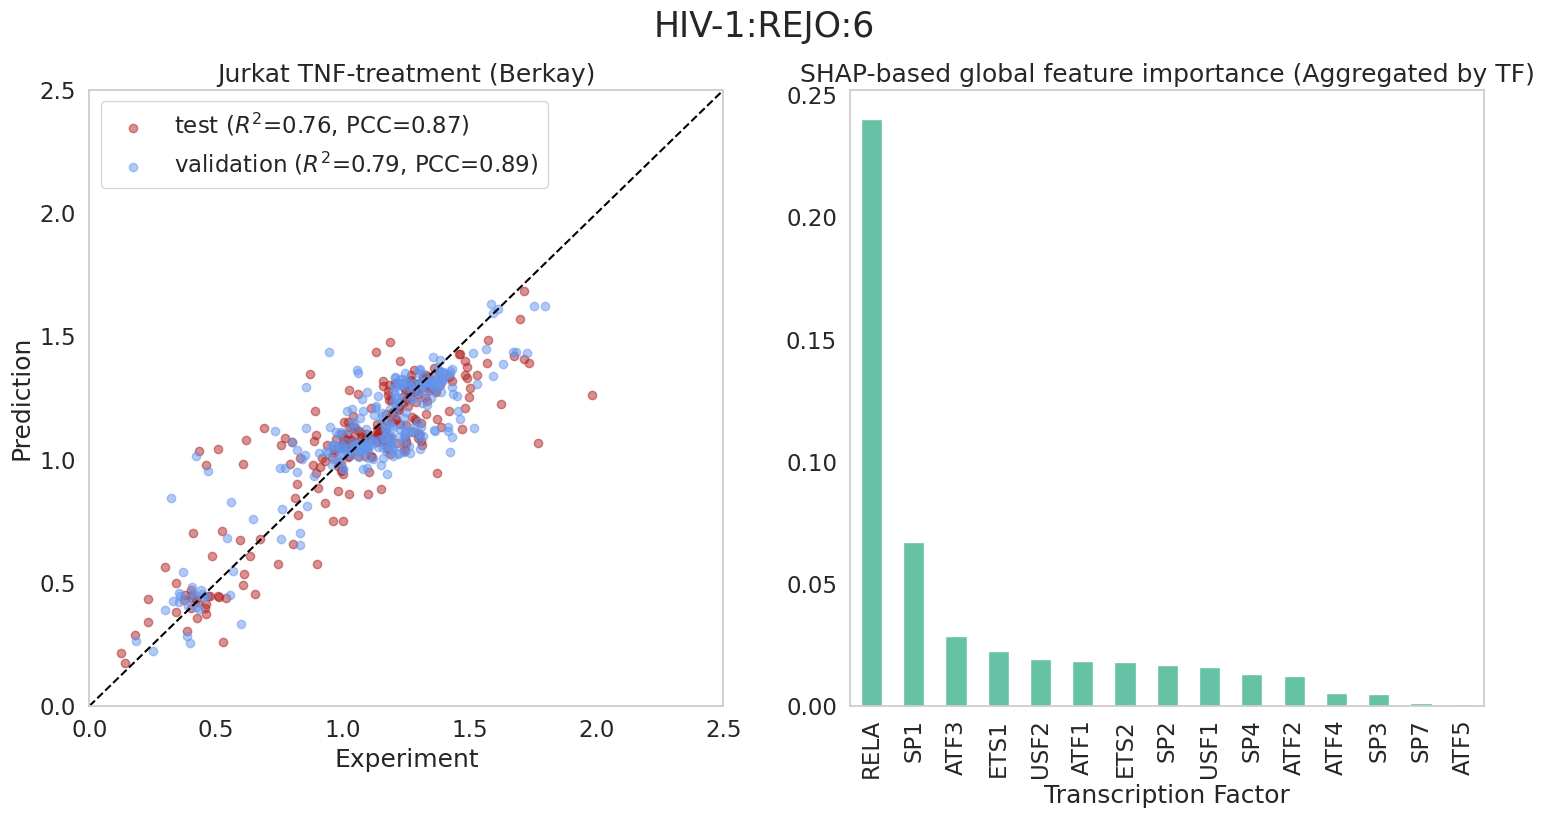

In [7]:
bst_trained = lgb.Booster(model_file=model_path)
val_pred = bst_trained.predict(X_val, num_iteration=bst_trained.best_iteration)
test_pred = bst_trained.predict(X_test, num_iteration=bst_trained.best_iteration)

test_r2 = r2_score(y_test, test_pred)
test_pcc = pearsonr(test_pred, y_test).statistic
val_r2 = r2_score(y_val, val_pred)
val_pcc = pearsonr(val_pred, y_val).statistic

fig, (ax_pred, ax_feature) = plt.subplots(figsize=(18, 8), ncols=2)
fig.suptitle(tile, fontsize=25)
ax_pred.scatter(y_test, test_pred, alpha=.5, color='firebrick', label=f'test ($R^2$={test_r2:.2}, PCC={test_pcc:.2})')
ax_pred.scatter(y_val, val_pred, alpha=.5, color='cornflowerblue', label=f'validation ($R^2$={val_r2:.2}, PCC={val_pcc:.2})')
ax_pred.plot([0, 5], [0, 5], ls='--', color='black')
ax_pred.set_xlabel('Experiment')
ax_pred.set_ylabel('Prediction')

ax_pred.set_title('Jurkat TNF-treatment (Berkay)')
ax_pred.set_xlim([0, 2.5])
ax_pred.set_ylim([0, 2.5])

# ax_pred.set_title(f'Jurkat Stimulation (CD3+PMA)')
# ax_pred.set_xlim([0, 4])
# ax_pred.set_ylim([0, 4])

ax_pred.legend(loc='upper left')
ax_pred.grid(False)


contribs = bst_trained.predict(X_val, pred_contrib=True)  # contribs_df = pd.DataFrame(contribs, columns=bst.feature_name() + ['bias'])
shap_values = contribs[:, :-1]
mean_abs_shap = np.abs(shap_values).mean(axis=0)
(
    pl.DataFrame({"feature": bst_trained.feature_name(), "importance": mean_abs_shap})
    .with_columns(
        pl.col("feature")
        .str.split("|")
        .list.get(1)
        .str.strip_chars("_")
        .alias("tf")
    )
    .group_by("tf")
    .agg(pl.col("importance").sum())
    .sort("importance", descending=True)
    .head(20)
    .to_pandas()
    .set_index("tf")
    .plot(ax=ax_feature, kind='bar', color='#66c2a5', legend=False)
)
ax_feature.set_title('SHAP-based global feature importance (Aggregated by TF)')
ax_feature.set_xlabel('Transcription Factor')
ax_feature.grid(False)
plt.savefig(DATA_DIR / "figures/larm_evaluation.pdf", format="pdf", bbox_inches="tight")
# plt.close()
